# Detectron2 Based Resistor Value Reader

<img src="https://dl.fbaipublicfiles.com/detectron2/Detectron2-Logo-Horz.png" width="500">

Welcome to detectron2! I LOVE FaceBook I mean META! Here's a very high-level overview of what's in the flow
* Run instance segmentations on an image of a circuit to extract ALL resistor instance
* Horizontally align all resistors and use INPAINT + CLAHE to remove Glare
* Run another detection model which will identify all instances of colour bands for each resistor instance!



# Get Data


In [1]:
!git clone 'https://github.com/AlexMIaoPU/remote-lab.git'

Cloning into 'remote-lab'...
remote: Enumerating objects: 1698, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 1698 (delta 0), reused 2 (delta 0), pack-reused 1692 (from 3)
Receiving objects: 100% (1698/1698), 368.99 MiB | 34.41 MiB/s, done.
Resolving deltas: 100% (96/96), done.
Updating files: 100% (1046/1046), done.


In [2]:
!pip install Dijkstar

In [3]:
!mv -v ./remote-lab/[!.]* ./

renamed './remote-lab/Colour_band_detection.ipynb' -> './Colour_band_detection.ipynb'
renamed './remote-lab/dataset' -> './dataset'
renamed './remote-lab/deprecated_modules' -> './deprecated_modules'
renamed './remote-lab/dijkstra_on_grid.ipynb' -> './dijkstra_on_grid.ipynb'
renamed './remote-lab/extracted_images' -> './extracted_images'
renamed './remote-lab/gird_extract.ipynb' -> './gird_extract.ipynb'
renamed './remote-lab/GridDijkstra.py' -> './GridDijkstra.py'
renamed './remote-lab/grid_oritentation.ipynb' -> './grid_oritentation.ipynb'
renamed './remote-lab/Grid.py' -> './Grid.py'
renamed './remote-lab/LossEvalHook.py' -> './LossEvalHook.py'
renamed './remote-lab/Mask.py' -> './Mask.py'
renamed './remote-lab/netlist_output' -> './netlist_output'
renamed './remote-lab/notebook_archive' -> './notebook_archive'
renamed './remote-lab/output' -> './output'
renamed './remote-lab/plug_classifier_resnet18_2.pth' -> './plug_classifier_resnet18_2.pth'
renamed './remote-lab/plug_data' -> '.

# Install detectron2

In [4]:
!python -m pip install pyyaml==5.1
import sys, os, distutils.core
# Note: This is a faster way to install detectron2 in Colab, but it does not include all functionalities (e.g. compiled operators).
# See https://detectron2.readthedocs.io/tutorials/install.html for full installation instructions
!git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

# Properly install detectron2. (Please do not install twice in both ways)
# !python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 13.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 15912, done.
remote: Total 15912 (delta 0), reused 0 (delta 0), pack-reused 15912 (from 1)
Receiving objects: 100% (15912/15912), 6.67 MiB | 18.26 MiB/s, done.
Resolving deltas: 100% (11332/11332), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.3 MB/s eta 0:00:00
  Prepar

In [5]:
!python --version

Python 3.12.12


In [1]:
import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2021 NVIDIA Corporation
Built on Sun_Feb_14_22:08:44_Pacific_Standard_Time_2021
Cuda compilation tools, release 11.2, V11.2.152
Build cuda_11.2.r11.2/compiler.29618528_0
torch:  2.8 ; cuda:  cpu
detectron2: 0.6


In [2]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random

# import some common detectron2 utilities
from detectron2.data import transforms as T
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

# Prepare Config files and load the two models

## Load training datasets to get metadata

In [3]:
from detectron2.data.datasets import register_coco_instances

register_coco_instances("my_dataset_train_seg", {}, "train_coco.json", "dataset/train")

# Now, get the metadata
resistor_meta = MetadataCatalog.get("my_dataset_train_seg")


register_coco_instances("my_dataset_train_detect", {}, "extracted_coco.json", "extracted_images")

# Now, get the metadata
colour_bands_meta = MetadataCatalog.get("my_dataset_train_detect")

In [4]:
print(colour_bands_meta)

# populate thing_classes from COCO json categories (fallback to manual list if absent)
import json, os
json_path = os.path.join("extracted_coco.json")
with open(json_path, "r", encoding="utf-8") as f:
    coco = json.load(f)
categories = [c.get("name") for c in coco.get("categories", [])]

if categories:
    colour_bands_meta.thing_classes = categories
else:
    # fallback — must match the order used during training
    colour_bands_meta.thing_classes = [
        "black","brown","red","orange","yellow","green","blue","violet","grey","white","gold"
    ]

print("thing_classes:", colour_bands_meta.thing_classes)


Metadata(name='my_dataset_train_detect', json_file='extracted_coco.json', image_root='extracted_images', evaluator_type='coco')
thing_classes: ['black', 'brown', 'red', 'orange', 'yellow', 'green', 'blue', 'violet', 'grey', 'white', 'gold']


## Create Configs


First, segmentation model

In [5]:
from detectron2.engine import DefaultTrainer

cfg_seg = get_cfg()
cfg_seg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg_seg.DATASETS.TRAIN = ("my_dataset_train_seg")
cfg_seg.DATASETS.TEST = ()
cfg_seg.DATALOADER.NUM_WORKERS = 2
cfg_seg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg_seg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg_seg.SOLVER.BASE_LR = 0.00025  # pick a good LR
cfg_seg.SOLVER.MAX_ITER = 500    # 500 iterations
cfg_seg.SOLVER.STEPS = []        # do not decay learning rate
cfg_seg.MODEL.DEVICE = "cpu"   # <--- force CPU
cfg_seg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg_seg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # only has one class (ballon). (see https://detectron2.readthedocs.io/tutorials/datasets.html#update-the-config-for-new-datasets)
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrect uses num_classes+1 here.


Next, Detection Model

In [7]:
cfg_detect = get_cfg()
cfg_detect.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg_detect.DATASETS.TRAIN = ("my_dataset_train_detect")
cfg_detect.DATASETS.TEST = ()
cfg_detect.DATALOADER.NUM_WORKERS = 2
cfg_detect.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg_detect.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg_detect.SOLVER.BASE_LR = 0.00005  # pick a good LR
cfg_detect.SOLVER.MAX_ITER = 2000    # 2000 iterations
cfg_detect.SOLVER.STEPS = []        # do not decay learning rate
cfg_detect.MODEL.DEVICE = "cpu"   # <--- force CPU
cfg_detect.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg_detect.MODEL.ROI_HEADS.NUM_CLASSES = 11

## Load the models from model files

In [8]:
seg_model_path = "E:/UNSW/Thesis/outPuts/seg/model_final3.pth"

cfg_seg.MODEL.WEIGHTS = seg_model_path  # path to the model we have uploaded/downloaded
cfg_seg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.75   # set a custom testing threshold
predictor_seg = DefaultPredictor(cfg_seg)

[11/07 16:31:02 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from E:/UNSW/Thesis/outPuts/seg/model_final3.pth ...


In [9]:
detection_model_path = "E:/UNSW/Thesis/outPuts/bands/model_final2.pth"

cfg_detect.MODEL.WEIGHTS = detection_model_path  # path to the model we have uploaded/downloaded
cfg_detect.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.75   # set a custom testing threshold
predictor_detect = DefaultPredictor(cfg_detect)

[11/07 16:31:04 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from E:/UNSW/Thesis/outPuts/bands/model_final2.pth ...


## Inference & evaluation using the trained model



Run inference on samples from the training dataset

In [ ]:
from detectron2.data.datasets import load_coco_json # Import the load_coco_json function
from detectron2.utils.visualizer import ColorMode
from PIL import Image
from Mask import extract_instance
from ResistorProcessing import image_horitzontal_alignment, remove_glare

dataset_dicts = load_coco_json("train_coco.json", "dataset/train")

for d in random.sample(dataset_dicts, 2):

    im = cv2.imread(d["file_name"])

    # Run the segmentation model
    outputs = predictor_seg(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
    v = Visualizer(im[:, :, ::-1],
                   metadata=resistor_meta,
                   scale=1,
                   instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels. This option is only available for segmentation models
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    

    # Get the masks
    masks = np.asarray(outputs["instances"].pred_masks.to("cpu"))

    # for each mask, extract the instance and process it, then run detection model on it
    for i, item_mask in enumerate(masks):

        extracted_image = extract_instance(item_mask, im)

        rotated = image_horitzontal_alignment(np.array(extracted_image))

        image_without_glare = remove_glare(rotated)

        outputs = predictor_detect(image_without_glare)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
        v = Visualizer(image_without_glare[:, :, ::-1],
                        metadata=colour_bands_meta,
                        scale=1,
                        instance_mode=ColorMode.IMAGE
        )
        out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
        

# Operate on a breadboard image

c:\Users\Alex Miao\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


1137 1262 641 692
Theta: 0.05168225045113891
Detected colors in order: ['red', 'violet']
Error extracting resistance: At least 4 color bands are required to calculate resistance.


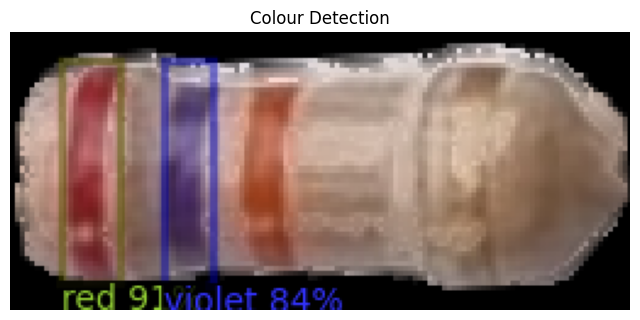

1709 1818 226 332
Theta: -0.754101738467918
Detected colors in order: ['gold', 'brown']
Error extracting resistance: At least 4 color bands are required to calculate resistance.


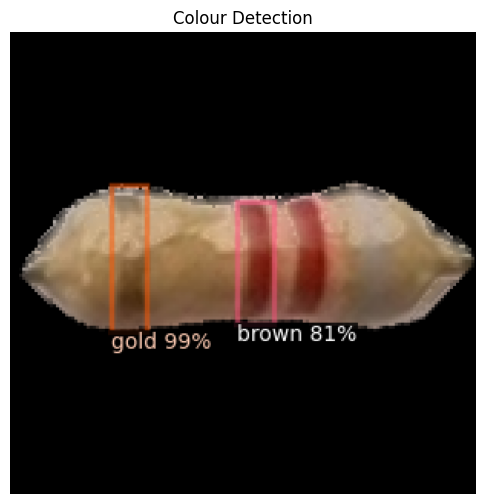

1075 1203 327 377
Theta: 0.04465736534580566
Detected colors in order: ['yellow', 'violet', 'gold']
Error extracting resistance: At least 4 color bands are required to calculate resistance.


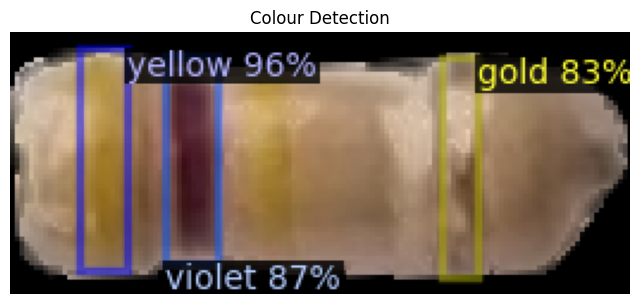

850 978 709 761
Theta: -0.06505185465790357
Detected colors in order: ['red', 'brown']
Error extracting resistance: At least 4 color bands are required to calculate resistance.


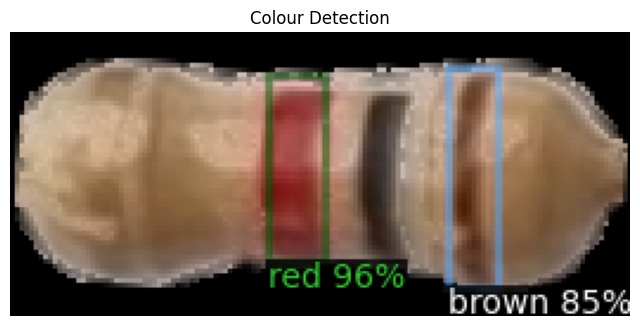

Detected 14 rows and 64 columns.
Grid size (average x difference): 50.627715074967846


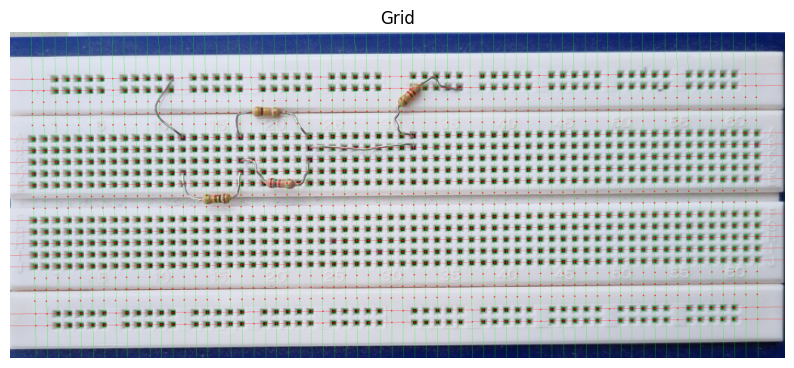

25


c:\Users\Alex Miao\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Alex Miao\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


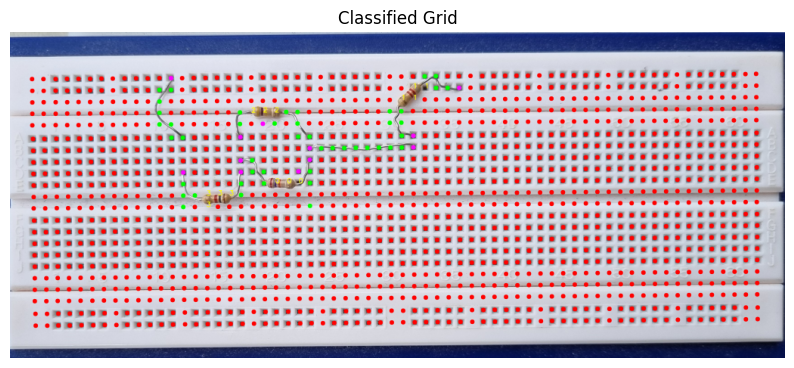

In [10]:
from detectron2.utils.visualizer import ColorMode
from PIL import Image
import matplotlib.pyplot as plt
from Mask import extract_instance
from ResistorProcessing import image_horitzontal_alignment, remove_glare, extract_resistance_from_predictor_output
from Grid import grid_generation, get_masked_grid_points, classify_grid_points, visualise_classified_grid_points

# Choose an image path
image_path = "test_images/wire6.jpg"

im = cv2.imread(image_path)

# Run the segmentation model
outputs = predictor_seg(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
v_seg = Visualizer(im[:, :, ::-1],
                metadata=resistor_meta,
                scale=1,
                instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
out = v_seg.draw_instance_predictions(outputs["instances"].to("cpu"))


# Get the masks
masks = np.asarray(outputs["instances"].pred_masks.to("cpu"))

resistances = []

# for each mask, extract the instance and process it, then run detection model on it
for i, item_mask in enumerate(masks):

    extracted_image = extract_instance(item_mask, im)

    rotated = image_horitzontal_alignment(np.array(extracted_image))

    image_without_glare = remove_glare(rotated)

    outputs_detect = predictor_detect(image_without_glare)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format

    # calculate resistance
    try:
        resistance = extract_resistance_from_predictor_output(outputs_detect)
        resistances.append(resistance)

    except Exception as e:
        print(f"Error extracting resistance: {e}")
        resistances.append(0)

    v_detect = Visualizer(image_without_glare[:, :, ::-1],
                    metadata=colour_bands_meta,
                    scale=2,
                    instance_mode=ColorMode.IMAGE
    )
    detection_out = v_detect.draw_instance_predictions(outputs_detect["instances"].to("cpu"))
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(detection_out.get_image()[:, :, ::-1], cv2.COLOR_BGR2RGB))
    plt.title("Colour Detection")
    plt.axis("off")
    plt.show()

# Run Grid generation
grid_img, intersections, grid_size, row_count, col_count = grid_generation(im)
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(grid_img, cv2.COLOR_BGR2RGB))
plt.title("Grid")
plt.axis("off")
plt.show()

# dilate the masks to cover larger area
size = int(grid_size/4) * 2 + 1
print(size)
kernel = np.ones((size,size),np.uint8)
masks_dilated = []
for mask in masks:
    dilated_mask = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1)
    masks_dilated.append(dilated_mask.astype(bool))


# get image dimensions
height, width = im.shape[:2]

gps = classify_grid_points(im, intersections, grid_size, height, width)

# Show all mask covered grid points
masked_grid_points = get_masked_grid_points(gps, masks_dilated)

class_grid_im = visualise_classified_grid_points(im, gps)
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(class_grid_im, cv2.COLOR_BGR2RGB))
plt.title("Classified Grid")
plt.axis("off")
plt.show()

# Run Dijkstra Solver

In [11]:
from GridDijkstra import GridDijkstraSolver, GridDijkstraSolver

all_plugged_gps = [gp for gp in gps if gp.is_plugged()]

# Run Dijkstra Solver
dijkstra_solver = GridDijkstraSolver(gps)

results = dijkstra_solver.run_dijkstra()

# Print the results
for res in results:
    print(res)

No path found from Plugged GP at (0, 12) to any Masked GP.
DijkstraResult(plugged_gp=(1, 37), masked_gp_id=1, total_cost=5, path=[(1, 37), (1, 36), (1, 35), (0, 35), (0, 34), (1, 34)])
DijkstraResult(plugged_gp=(4, 20), masked_gp_id=2, total_cost=5, path=[(4, 20), (4, 21), (3, 22), (3, 21)])
DijkstraResult(plugged_gp=(5, 18), masked_gp_id=2, total_cost=3, path=[(5, 18), (4, 18), (3, 18), (3, 19)])
DijkstraResult(plugged_gp=(5, 33), masked_gp_id=1, total_cost=4, path=[(5, 33), (5, 32), (4, 32), (3, 32), (2, 32)])
DijkstraResult(plugged_gp=(6, 24), masked_gp_id=0, total_cost=7, path=[(6, 24), (6, 25), (7, 24), (8, 24), (9, 24), (9, 23)])
DijkstraResult(plugged_gp=(6, 33), masked_gp_id=1, total_cost=6, path=[(6, 33), (5, 32), (4, 32), (3, 32), (2, 32)])
DijkstraResult(plugged_gp=(7, 18), masked_gp_id=0, total_cost=5, path=[(7, 18), (7, 19), (8, 19), (8, 20), (9, 20), (9, 21)])
DijkstraResult(plugged_gp=(7, 24), masked_gp_id=0, total_cost=3, path=[(7, 24), (8, 24), (9, 24), (9, 23)])
Dijks

In [13]:
# print all plugged grid points
for gp in all_plugged_gps:
    print(gp)

GP of type 2 at Point on row 0, col 12 of (709.9490372896231, 202.9319025161981) with probs [0.79628587 0.09769272 0.10602144] and borders ([1], []), masked: False
GP of type 2 at Point on row 1, col 37 of (1980.5338139251508, 245.73363592452554) with probs [0.17067641 0.5847033  0.24462025] and borders ([], [-1]), masked: False
GP of type 2 at Point on row 4, col 20 of (1115.3149898929569, 403.7913968016118) with probs [0.88440317 0.0694776  0.04611937] and borders ([], [1]), masked: False
GP of type 2 at Point on row 5, col 18 of (1016.2087958771108, 463.42549356457204) with probs [0.00218576 0.07142572 0.9263885 ] and borders ([-1], []), masked: False
GP of type 2 at Point on row 5, col 33 of (1778.6314018661685, 456.9501808835828) with probs [0.01216372 0.1851231  0.80271316] and borders ([], [-1]), masked: False
GP of type 2 at Point on row 6, col 24 of (1321.9635302630854, 512.176088063783) with probs [0.01110747 0.02508585 0.9638067 ] and borders ([], [1]), masked: False
GP of t

# From Dijkstra Results, produce NetList (LTSpice Format)

In [ ]:
from ResistorProcessing import ResistorResult

# reset gp node_ids
for gp in all_plugged_gps:
    gp.node_id = None

# For each resistor (masked_gp), find two plugged_gp with the lowest cost

# List of ResistorResult
rest_results = []
unique_plugged_gps_list = []

for i, resistance in enumerate(resistances):
    corresponding_results = [res for res in results if res.masked_gp_id == i]
    # sort the results by cost
    corresponding_results.sort(key=lambda x: x.total_cost)

    # Select the top 2 results with the lowest cost
    top_results = corresponding_results[:2]

    if len(top_results) >= 2:
      rest_result = ResistorResult(resistance=resistance, id=i, plugged_gps=[top_results[0].plugged_gp, top_results[1].plugged_gp])
      rest_results.append(rest_result)
      print(rest_result)
    else:
      print(f"Not enough Dijkstra results for masked_gp Resistor {i}")

# Collect all unique plugged grid points
unique_plugged_gps = {}
for res in rest_results:
    for gp in res.plugged_gps:
        unique_plugged_gps[gp.get_index()] = gp  # using a dictionary to avoid duplicates
unique_plugged_gps_list = list(unique_plugged_gps.values())

# Find all the plugged GPs that not belong to any resistor connections
non_res_plugged_gps = [gp for gp in all_plugged_gps if gp not in unique_plugged_gps_list]

# Find all wire connected plugged GP pairs
wire_connected_gp_pairs = dijkstra_solver.find_wire_connected_gps(non_res_plugged_gps)
print(wire_connected_gp_pairs)

# If the GPs are in row 5-9 and in same col, they can be treated as the same point,
# likewise if the GPs are in row 12-16 and in same col, they can be treated as the same point.
# Assign node ids to unique plugged grid points
node_id = 1
for gp in unique_plugged_gps_list:
    if gp.node_id is not None:
        continue  # already assigned
    if gp.get_index()[0] in range(5, 10):
        gp.node_id = node_id
        # assign same node_id to all GPs in the same col and row 5-9
        for other_gp in all_plugged_gps:
            if other_gp.get_index()[1] == gp.get_index()[1] and other_gp.get_index()[0] in range(5, 10):
                other_gp.node_id = node_id
        node_id += 1
    elif gp.get_index()[0] in range(12, 17):
        gp.node_id = node_id
        # assign same node_id to all GPs in the same col and row 12-16
        for other_gp in all_plugged_gps:
            if other_gp.get_index()[1] == gp.get_index()[1] and other_gp.get_index()[0] in range(12, 17):
                other_gp.node_id = node_id
        node_id += 1
    else:
        gp.node_id = node_id
        node_id += 1


# Hardcoded list of Voltage supply nodes
# Assume Positive supply on top rail
top_power_supply_node_ids = (999,1000)
bottom_power_supply_node_ids = (1001,1002)

# Top and bottom power rails, find out if any plugged GPs are on the power rail, get their node ids, assign them the same node id
top_rail_v_node = set()
top_rail_gnd_node = set()
bottom_rail_v_node = set()
bottom_rail_gnd_node = set()
for gp in unique_plugged_gps_list:
    if gp.get_index()[0] == 0:  # top power rail row index
        top_rail_v_node.add(gp)
    elif gp.get_index()[0] == 1:  # top gnd rail row index
        top_rail_gnd_node.add(gp)
    elif gp.get_index()[0] == row_count - 2:  # bottom gnd rail row index
        bottom_rail_gnd_node.add(gp)
    elif gp.get_index()[0] == row_count - 1:  # bottom power rail row index
        bottom_rail_v_node.add(gp)

# Assign same node id to all top rail V nodes

for gp in top_rail_v_node:
    gp.node_id = top_power_supply_node_ids[0]
for gp in top_rail_gnd_node:
    gp.node_id = top_power_supply_node_ids[1]
for gp in bottom_rail_gnd_node:
    gp.node_id = bottom_power_supply_node_ids[0]
for gp in bottom_rail_v_node:
    gp.node_id = bottom_power_supply_node_ids[1]


# For all pairs of GPs present in wire_connected_gp_pairs, assign them the same node id
for gp1, gp2 in wire_connected_gp_pairs:
    # Check both have node ids
    if gp1.node_id is None or gp2.node_id is None:
        continue
    # assign the smaller node id to both
    min_node_id = min(gp1.node_id, gp2.node_id)

    # also convert other GPs with same node id to min_node_id
    for gp in all_plugged_gps:
        if gp.node_id == gp1.node_id or gp.node_id == gp2.node_id:
            gp.node_id = min_node_id


ResistorResult(resistance=0, id=0, plugged_gps=[GP of type 2 at Point on row 1, col 42 of (2625.7523676172714, 269.031414013617) with probs [0.06712551 0.41406837 0.51880616] and borders ([], [1]), masked: False, GP of type 2 at Point on row 5, col 47 of (2919.193733174994, 507.80360715466685) with probs [0.03701987 0.03999721 0.92298293] and borders ([-1], [1]), masked: False])
ResistorResult(resistance=np.int64(47000), id=1, plugged_gps=[GP of type 2 at Point on row 9, col 47 of (2920.1457503220854, 743.1102007089065) with probs [0.00267662 0.22727767 0.7700457 ] and borders ([], [1]), masked: False, GP of type 2 at Point on row 16, col 49 of (3039.403364921368, 1157.6605108186575) with probs [0.11643527 0.01452234 0.8690424 ] and borders ([-1], []), masked: False])
ResistorResult(resistance=np.int64(33000), id=2, plugged_gps=[GP of type 2 at Point on row 0, col 37 of (2331.984937134234, 209.103454012552) with probs [0.01145402 0.37494063 0.6136054 ] and borders ([1], []), masked: Fa

: 

# Create Netlist file from Resistor Results

In [28]:
# Create a blank file called "netlist.net"
with open("netlist.net", "w") as f:
    f.write("* This is an autogenerated netlist file\n")
    # Write the power supply nodes
    f.write(f"V1 N{top_power_supply_node_ids[0]} N{top_power_supply_node_ids[1]} V\n")
    f.write(f"V2 N{bottom_power_supply_node_ids[0]} N{bottom_power_supply_node_ids[1]} V\n")
    for i, res in enumerate(rest_results):
        f.write(f"R{i} N{res.plugged_gps[0].node_id} N{res.plugged_gps[1].node_id} {res.resistance}\n")
    f.write(".backanno\n.end\n")

# Misc Testing Stuff

In [ ]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
evaluator = COCOEvaluator("my_dataset_val", output_dir="./output")
val_loader = build_detection_test_loader(cfg, "my_dataset_val")
print(inference_on_dataset(predictor.model, val_loader, evaluator))
# another equivalent way to evaluate the model is to use `trainer.test`

[05/23 07:45:58 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
[05/23 07:45:58 d2.data.datasets.coco]: Loaded 27 images in COCO format from val_coco.json
[05/23 07:45:58 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[05/23 07:45:58 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[05/23 07:45:58 d2.data.common]: Serializing 27 elements to byte tensors and concatenating them all ...
[05/23 07:45:58 d2.data.common]: Serialized dataset takes 0.01 MiB
[05/23 07:45:58 d2.evaluation.evaluator]: Start inference on 27 batches
[05/23 07:46:00 d2.evaluation.evaluator]: Inference done 11/27. Dataloading: 0.0013 s/iter. Inference: 0.1029 s/iter. Eval: 0.0013 s/iter. Total: 0.1055 s/iter. ETA=0:00:01
[05/23 07:46:02 d2.evaluation.evaluator]: Total inference time: 0:00:02.629872 (0.1